##### Import libraries

In [ ]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6fc56fe064d4ff87cd70bd7b6b2d61ac610ce253cc905af1cd2b26cbae0bde84
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import defaultdict
from sentence_transformers import SentenceTransformer, models
from sklearn.cluster import AgglomerativeClustering
from collections import Counter
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
import shap
import ast
import joblib
import lime
import lime.lime_tabular
from lime.lime_tabular import LimeTabularExplainer
warnings.filterwarnings('ignore')

##### Read data

In [ ]:
data = pd.read_csv("final_ml_data.csv")
data.head()

,subject_id,text,gender,dod,mortality,dischtime,race,marital_status,number_of_readmissions,age_group,stroke_class,admittime_date,blood_pressure,entities
0,10081794,Name: ___ Unit No: ___ Admiss...,F,NaN,0,28/10/2161 15:15,WHITE,DIVORCED,1,65–74,History of TIA,21/10/2161,normal,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA..."
1,10083062,Name: ___ Unit No: ___...,F,NaN,0,03/11/2171 19:13,WHITE,SINGLE,0,65–74,History of TIA,31/10/2171,120/50,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D..."
2,10085941,Name: ___ Unit No: ___ ...,F,18/04/2142,1,21/03/2142 13:30,BLACK/AFRICAN AMERICAN,SINGLE,0,75–84,Hemorrhagic stroke,17/03/2142,125/80,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG..."
3,10086861,Name: ___ Unit No: __...,F,NaN,0,21/11/2131 18:20,WHITE,MARRIED,0,65–74,Ischemic stroke,20/11/2131,161/64,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',..."
4,10087948,Name: ___ Unit No: ___ ...,M,14/05/2115,1,25/04/2115 14:30,WHITE,MARRIED,0,75–84,History of TIA,21/04/2115,140/78,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ..."


In [ ]:
data.columns

Index(['subject_id', 'text', 'gender', 'dod', 'mortality', 'dischtime', 'race',
       'marital_status', 'number_of_readmissions', 'age_group', 'stroke_class',
       'admittime_date', 'blood_pressure', 'entities'],
      dtype='object')

##### Drop columns that are not useful for training

In [ ]:
data = data[['subject_id','gender', 'dod', 'mortality', 'dischtime', 'race', 'marital_status',
       'number_of_readmissions', 'age_group', 'stroke_class', 'admittime_date', 'blood_pressure', 'entities']]
data.head()

,subject_id,gender,dod,mortality,dischtime,race,marital_status,number_of_readmissions,age_group,stroke_class,admittime_date,blood_pressure,entities
0,10081794,F,NaN,0,28/10/2161 15:15,WHITE,DIVORCED,1,65–74,History of TIA,21/10/2161,normal,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA..."
1,10083062,F,NaN,0,03/11/2171 19:13,WHITE,SINGLE,0,65–74,History of TIA,31/10/2171,120/50,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D..."
2,10085941,F,18/04/2142,1,21/03/2142 13:30,BLACK/AFRICAN AMERICAN,SINGLE,0,75–84,Hemorrhagic stroke,17/03/2142,125/80,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG..."
3,10086861,F,NaN,0,21/11/2131 18:20,WHITE,MARRIED,0,65–74,Ischemic stroke,20/11/2131,161/64,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',..."
4,10087948,M,14/05/2115,1,25/04/2115 14:30,WHITE,MARRIED,0,75–84,History of TIA,21/04/2115,140/78,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ..."


In [ ]:
data.isnull().sum()

,0
subject_id,0
gender,0
dod,957
mortality,0
dischtime,0
race,0
marital_status,0
number_of_readmissions,0
age_group,0
stroke_class,0


In [ ]:
len(data)

1513

In [ ]:
data["mortality"].value_counts()

,count
mortality,
0,957
1,556


### Data Preprocessing - Feature encoding

##### One-hot encoding for the sex column

In [ ]:
df = pd.get_dummies(data, columns=["gender"], prefix="Sex", drop_first=False, dtype=int)

##### Classify races as "white" and "non-white", then perform one-hot encoding

In [ ]:
df["race"] = df["race"].str.upper()
df["race"] = df["race"].apply(lambda x: "White" if "WHITE" in x else "Non-White")
df["race"].value_counts()

,count
race,
WHITE,1070
NON-WHITE,443


In [ ]:
df = pd.get_dummies(df, columns=["race"], prefix="race", drop_first=False, dtype=int)

##### One-hot encoding for the stroke class and care level (marital status) columns

In [ ]:
df = pd.get_dummies(df, columns=["stroke_class"], prefix="sc", drop_first=False, dtype=int)

In [ ]:
care_level_map = {"SINGLE": "medium", "MARRIED": "high", "WIDOWED": "low", "DIVORCED": "medium"}

In [ ]:
df["marital_status"] = df["marital_status"].map(care_level_map)

In [ ]:
df = pd.get_dummies(df, columns=["marital_status"], prefix="care_level", drop_first=False, dtype=int)

##### Binary encoding for the readmissions column

In [ ]:
df["number_of_readmissions"] = df["number_of_readmissions"].astype(int)
df["readmissions"] = (df["number_of_readmissions"] > 0).astype(int)

##### Classify blood pressure values as normal or abnormal, then perform binary encoding

In [ ]:
def classify_bp(value):
    # Handle nulls safely
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Explicit label handling
    if value in ["normal"]:
        return "normal"
    if value in ["low", "high", "abnormal"]:
        return "abnormal"

    # Numeric BP (e.g. "120/80")
    try:
        systolic, diastolic = map(int, value.split("/"))

        if 91 <= systolic <= 129 and 61 <= diastolic <= 84:
            return "normal"
        else:
            return "abnormal"

    except Exception:
        return "abnormal"


In [ ]:
df["blood_pressure"] = df["blood_pressure"].apply(classify_bp)

In [ ]:
df["blood_pressure"].value_counts()

,count
blood_pressure,
abnormal,1212
normal,301


In [ ]:
df["blood_pressure"] = df["blood_pressure"].map({"abnormal": 1,"normal": 0})

##### Ordinal encoding for the age group column

In [ ]:
age_group_mapping = {"18–44": 1, "45–64": 2, "65-74": 3, "75–84": 4, "85+": 5}

In [ ]:
df["age_group"] = df["age_group"].map(age_group_mapping)

##### Prepare the entities for training. The pipeline consists of:  
1) Using embeddings to select top-K canonical entities per class  
2) Encoding the entities features using class normalized counts and binary presence of the selected canonical entities from step 1

In [ ]:
# Function to create a list of entity dictionaries
def parse_entities(entity_list):
    parsed = []
    for e in entity_list:
        text, cls = e.split(":")
        parsed.append({
            "text": text.strip().lower(),
            "class": cls.strip()
        })
    return parsed

In [ ]:
word_model = models.Transformer("emilyalsentzer/Bio_ClinicalBERT")
pooling = models.Pooling(
    word_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True)
bcbert = SentenceTransformer(modules=[word_model, pooling])
def embed_texts(texts):
    return bcbert.encode(texts, normalize_embeddings=True)

In [ ]:
# Function to create a cluster of entities within each class
def cluster_entities(entities, distance_threshold=0.25):
    """
    entities: list of dicts with keys ['text', 'class']
    """
    grouped = defaultdict(list)
    for e in entities:
        grouped[e["class"]].append(e["text"])

    canonical_map = {}

    for cls, texts in grouped.items():
        embeddings = embed_texts(texts)

        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=distance_threshold,
            metric="cosine",
            linkage="average"
        )
        labels = clustering.fit_predict(embeddings)

        clusters = defaultdict(list)
        for text, label in zip(texts, labels):
            clusters[label].append(text)

        # choose canonical name (most frequent or shortest)
        for cluster_texts in clusters.values():
            canonical = sorted(cluster_texts, key=len)[0]
            for t in cluster_texts:
                canonical_map[(t, cls)] = canonical

    return canonical_map

In [ ]:
# Function to build vocabulary of top K words per class
def build_vocabulary(all_entities, canonical_map, top_k=20):
    """
    all_entities: list of parsed entities from training data
    """
    counter = defaultdict(Counter)

    for e in all_entities:
        canonical = canonical_map[(e["text"], e["class"])]
        counter[e["class"]][canonical] += 1

    vocab = {
        cls: [term for term, _ in counts.most_common(top_k)]
        for cls, counts in counter.items()
    }

    return vocab

In [ ]:
# Function to encode entities
def encode_entities(entities, vocab):
    counts = Counter()

    if not isinstance(entities, list):
        return {k: 0.0 for k in vocab}

    for e in entities:
        if not isinstance(e, str):
            continue

        # Split ONLY on the last colon
        parts = e.rsplit(":", 1)
        if len(parts) != 2:
            continue

        cls = parts[1].strip()
        counts[cls] += 1

    total = sum(counts.values()) or 1

    features = {}
    for feature_name, cls in vocab.items():
        features[feature_name] = counts.get(cls, 0) / total

    return features


##### Create the target column: time to mortality

In [ ]:
def remove_time(df, column):
  return df[column].dt.strftime("%Y-%m-%d")

In [ ]:
df["dischtime"] = pd.to_datetime(df["dischtime"])
df["dischtime"] = remove_time(df, "dischtime")

In [ ]:
df["time_to_mortality"] = (pd.to_datetime(df["dod"]) - pd.to_datetime(df["admittime_date"])).dt.days
df["time_to_mortality"] = df["time_to_mortality"].fillna((pd.to_datetime(df["dischtime"]) - pd.to_datetime(df["admittime_date"])).dt.days)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   subject_id                              1513 non-null   int64  
 1   dod                                     556 non-null    object 
 2   mortality                               1513 non-null   int64  
 3   dischtime                               1513 non-null   object 
 4   number_of_readmissions                  1513 non-null   int64  
 5   age_group                               1151 non-null   float64
 6   admittime_date                          1513 non-null   object 
 7   blood_pressure                          1513 non-null   int64  
 8   entities                                1513 non-null   object 
 9   Sex_F                                   1513 non-null   int64  
 10  Sex_M                                   1513 non-null   int6

In [ ]:
df.head(10)

,subject_id,dod,mortality,dischtime,number_of_readmissions,age_group,admittime_date,blood_pressure,entities,Sex_F,...,sc_Hemorrhagic stroke,sc_Hemorrhagic stroke + history of TIA,sc_History of TIA,sc_Ischemic stroke,sc_Ischemic stroke + history of TIA,care_level_high,care_level_low,care_level_medium,readmissions,time_to_mortality
0,10081794,NaN,0,2161-10-28,1,NaN,21/10/2161,0,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA...",1,...,0,0,1,0,0,0,0,1,1,7.0
1,10083062,NaN,0,2171-11-03,0,NaN,31/10/2171,1,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D...",1,...,0,0,1,0,0,0,0,1,0,3.0
2,10085941,18/04/2142,1,2142-03-21,0,4.0,17/03/2142,0,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG...",1,...,1,0,0,0,0,0,0,1,0,32.0
3,10086861,NaN,0,2131-11-21,0,NaN,20/11/2131,1,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',...",1,...,0,0,0,1,0,1,0,0,0,1.0
4,10087948,14/05/2115,1,2115-04-25,0,4.0,21/04/2115,1,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ...",0,...,0,0,1,0,0,1,0,0,0,23.0
5,10088163,NaN,0,2124-01-27,0,NaN,25/01/2124,1,"['renal: BIOLOGICAL_STRUCTURE', '\x93: SEVERIT...",0,...,0,0,1,0,0,1,0,0,0,2.0
6,10088799,NaN,0,2168-07-16,0,5.0,15/07/2168,0,"['shortness of breath: SIGN_SYMPTOM', 'Atenolo...",1,...,0,0,0,1,0,1,0,0,0,1.0
7,10088966,05/06/2132,1,2131-12-13,1,4.0,29/11/2131,1,"['Atorvastatin: MEDICATION', 'PO: DOSAGE', 'Me...",0,...,0,0,0,1,0,1,0,0,1,189.0
8,10089244,21/02/2128,1,2128-02-21,0,NaN,09/02/2128,1,"['scopolamine: MEDICATION', 'is: DOSAGE', 'ggt...",1,...,0,0,0,1,0,1,0,0,0,12.0
9,10089730,NaN,0,2134-09-22,0,NaN,17/09/2134,1,"['mass: SIGN_SYMPTOM', 'hypertrophy: SIGN_SYMP...",1,...,0,0,0,1,0,1,0,0,0,5.0


In [ ]:
df["time_to_mortality"] = df["time_to_mortality"].astype(int)

In [ ]:
df["time_to_mortality"].max()

2650

In [ ]:
print("Latest date of death:", pd.to_datetime(df['dod']).max().strftime("%Y-%m-%d"))
print("Latest date of admission:", pd.to_datetime(df['admittime_date']).max().strftime("%Y-%m-%d"))

Latest date of death: 2207-01-22
Latest date of admission: 2208-10-24


##### Split data into features and target, and training and test set

In [ ]:
df.columns

Index(['subject_id', 'dod', 'mortality', 'dischtime', 'number_of_readmissions',
       'age_group', 'admittime_date', 'blood_pressure', 'entities', 'Sex_F',
       'Sex_M', 'race_NON-WHITE', 'race_WHITE', 'sc_Hemorrhagic stroke',
       'sc_Hemorrhagic stroke + history of TIA', 'sc_History of TIA',
       'sc_Ischemic stroke', 'sc_Ischemic stroke + history of TIA',
       'care_level_high', 'care_level_low', 'care_level_medium',
       'readmissions', 'time_to_mortality'],
      dtype='object')

In [ ]:
count = ((df['time_to_mortality'] <= 90) & (df["mortality"] == 1)).sum()
print(f"Number of values less than or equal to 90: {count}")

Number of values less than or equal to 90: 415


###### Create feature correlation plots

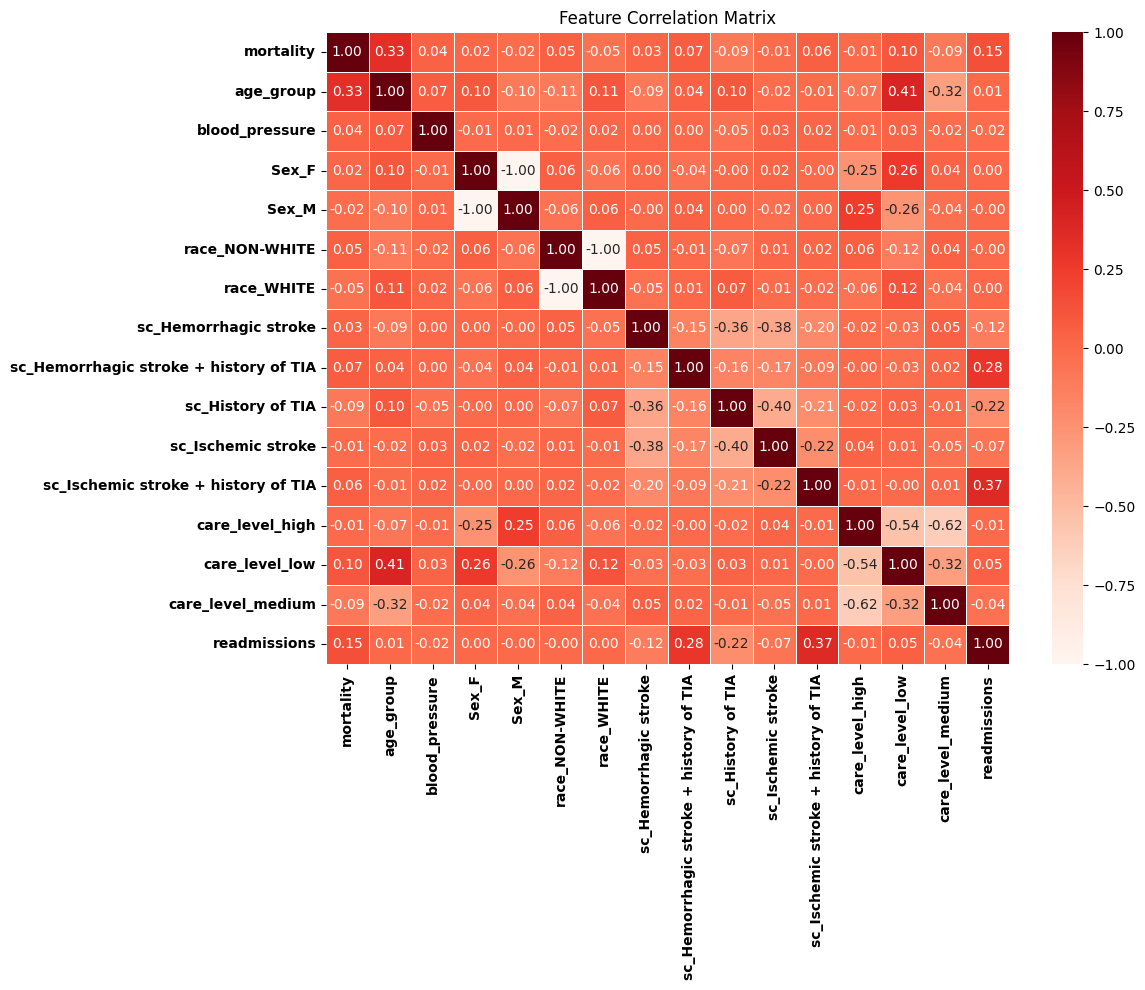

In [ ]:
df_corr = df.drop(["dod","subject_id", "dischtime", "number_of_readmissions", "admittime_date","entities", "time_to_mortality"], axis=1)
corr_matrix = df_corr.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="Reds", fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_plot3.png", dpi=500)
plt.show()

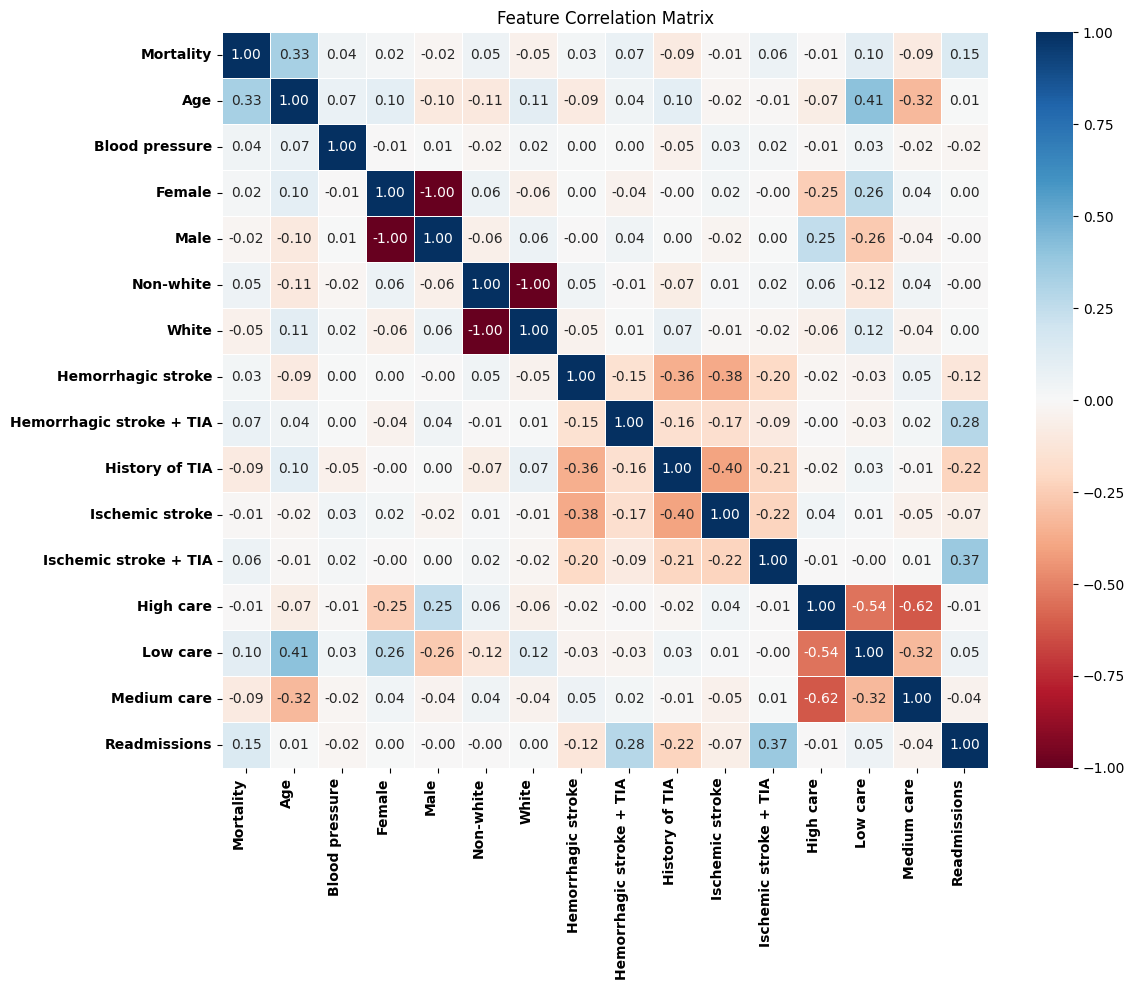

In [ ]:
# Create a mapping from original variable names to display-friendly names
label_map = {
    "age_group": "Age",
    "blood_pressure": "Blood pressure",
    "Sex_F": "Female",
    "Sex_M": "Male",
    "race_WHITE": "White",
    "race_NON-WHITE": "Non-white",
    "sc_Hemorrhagic stroke": "Hemorrhagic stroke",
    "sc_Ischemic stroke": "Ischemic stroke",
    "sc_History of TIA": "History of TIA",
    "sc_Hemorrhagic stroke + history of TIA": "Hemorrhagic stroke + TIA",
    "sc_Ischemic stroke + history of TIA": "Ischemic stroke + TIA",
    "care_level_low": "Low care",
    "care_level_medium": "Medium care",
    "care_level_high": "High care",
    "readmissions": "Readmissions",
    "mortality": "Mortality"
}

# Apply renaming to correlation matrix
corr_matrix_renamed = corr_matrix.rename(
    index=label_map,
    columns=label_map
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_renamed,
    annot=True,
    cmap="RdBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.xticks(rotation=90, ha="right", fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_plot4.png", dpi=500)
plt.show()

###### Encode the entities column

In [ ]:
ENTITY_CLASSES = ["DOSAGE", "MEDICATION", "SIGN_SYMPTOM", "DISEASE_DISORDER", "BIOLOGICAL_STRUCTURE",
                  "LAB_VALUE", "DIAGNOSTIC_PROCEDURE", "SEVERITY", "THERAPEUTIC_PROCEDURE",
                  "CLINICAL_EVENT", "DETAILED_DESCRIPTION", "DURATION"]
vocab = {f"{cls}": cls for cls in ENTITY_CLASSES}

In [ ]:
X_structured = df.drop(["mortality", "time_to_mortality", "dod", "dischtime", "admittime_date", "number_of_readmissions", "entities"], axis=1)

In [ ]:
df["entities"] = df["entities"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
X_entities = df["entities"].apply(lambda x: encode_entities(x, vocab))
X_entities_df = pd.DataFrame(X_entities.tolist()).fillna(0)

In [ ]:
X = pd.concat([X_structured.reset_index(drop=True), X_entities_df.reset_index(drop=True)], axis=1)

In [ ]:
horizons = [1, 15, 30, 45, 60, 90]

In [ ]:
targets = {}
for h in horizons:
    # Patient died by day h: only if mortality=1 AND time_to_mortality <= h
    died_by_h = (df['mortality'] == 1) & (df['time_to_mortality'] <= h)

    # Censored before day h: patient left hospital/censored before we could observe day h
    censored_before_h = (df['mortality'] == 0) & (df['time_to_mortality'] < h)

    # Create target: 1 if died, 0 if alive at day h
    # Exclude patients censored before day h (we don't know their status)
    targets[f'died_by_day_{h}'] = died_by_h.astype(int)
    targets[f'observable_at_day_{h}'] = ~censored_before_h  # Can we observe this patient at day h?

In [ ]:
y_df = pd.DataFrame(targets)

In [ ]:
print("\nTarget Distribution:")
for h in horizons:
    observable = y_df[f'observable_at_day_{h}'].sum()
    deaths = y_df.loc[y_df[f'observable_at_day_{h}'], f'died_by_day_{h}'].sum()
    rate = deaths / observable if observable > 0 else 0
    print(f"Day {h:3d}: {deaths:4d} deaths / {observable:4d} observable = {rate:.1%} death rate")


Target Distribution:
Day   1:   45 deaths / 1497 observable = 3.0% death rate
Day  15:  249 deaths /  627 observable = 39.7% death rate
Day  30:  319 deaths /  565 observable = 56.5% death rate
Day  45:  367 deaths /  559 observable = 65.7% death rate
Day  60:  386 deaths /  556 observable = 69.4% death rate
Day  90:  415 deaths /  556 observable = 74.6% death rate


In [ ]:
patient_ids = df["subject_id"].unique()
train_patients, test_patients = train_test_split(
    patient_ids, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
train_mask = df["subject_id"].isin(train_patients)
test_mask = df["subject_id"].isin(test_patients)

In [ ]:
X_train_base = X[train_mask].reset_index(drop=True)
X_test_base = X[test_mask].reset_index(drop=True)
y_train_df = y_df[train_mask].reset_index(drop=True)
y_test_df = y_df[test_mask].reset_index(drop=True)

In [ ]:
X_train_base = X_train_base.drop('subject_id', axis=1)
X_test_base = X_test_base.drop('subject_id', axis=1)

In [ ]:
assert set(train_patients).isdisjoint(set(test_patients))
print(f"\nTrain set: {len(X_train_base)} patients")
print(f"Test set: {len(X_test_base)} patients")
print(f"Number of features: {X_train_base.shape[1]}")


Train set: 1210 patients
Test set: 303 patients
Number of features: 27


In [ ]:
# Expanding data
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

In [ ]:
for h in horizons:
    train_observable = y_train_df[f'observable_at_day_{h}']

    X_train_h = X_train_base[train_observable].copy()
    X_train_h['horizon'] = h  # Add time as a feature

    # Get corresponding outcomes
    y_train_h = y_train_df.loc[train_observable, f'died_by_day_{h}']

    X_train_list.append(X_train_h)
    y_train_list.append(y_train_h)

    print(f"Day {h:3d} - Train: {len(X_train_h)} samples, Event rate: {y_train_h.mean():.3f}")

    # Test data
    test_observable = y_test_df[f'observable_at_day_{h}']

    X_test_h = X_test_base[test_observable].copy()
    X_test_h['horizon'] = h

    y_test_h = y_test_df.loc[test_observable, f'died_by_day_{h}']

    X_test_list.append(X_test_h)
    y_test_list.append(y_test_h)

    print(f"Day {h:3d} - Test:  {len(X_test_h)} samples, Event rate: {y_test_h.mean():.3f}")

Day   1 - Train: 1196 samples, Event rate: 0.029
Day   1 - Test:  301 samples, Event rate: 0.033
Day  15 - Train: 502 samples, Event rate: 0.388
Day  15 - Test:  125 samples, Event rate: 0.432
Day  30 - Train: 454 samples, Event rate: 0.568
Day  30 - Test:  111 samples, Event rate: 0.550
Day  45 - Train: 449 samples, Event rate: 0.661
Day  45 - Test:  110 samples, Event rate: 0.636
Day  60 - Train: 447 samples, Event rate: 0.698
Day  60 - Test:  109 samples, Event rate: 0.679
Day  90 - Train: 447 samples, Event rate: 0.752
Day  90 - Test:  109 samples, Event rate: 0.725


In [ ]:
X_train_expanded = pd.concat(X_train_list, ignore_index=True)
y_train_expanded = pd.concat(y_train_list, ignore_index=True)

X_test_expanded = pd.concat(X_test_list, ignore_index=True)
y_test_expanded = pd.concat(y_test_list, ignore_index=True)

In [ ]:
print("Length of training set: ", len(X_train_expanded))
print("Length of test set: ", len(X_test_expanded))

Length of training set:  3495
Length of test set:  865


In [ ]:
xgboost = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, learning_rate=0.05, n_estimators=200, random_state=42,
    scale_pos_weight=len(y_train_expanded[y_train_expanded == 0]) / len(y_train_expanded[y_train_expanded == 1]))
xgboost.fit(X_train_expanded, y_train_expanded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
predictions = {}

for h in horizons:
    # Get test data for this horizon
    test_observable = y_test_df[f'observable_at_day_{h}']
    X_test_h = X_test_base[test_observable].copy()
    X_test_h['horizon'] = h  # Set horizon feature

    y_test_h = y_test_df.loc[test_observable, f'died_by_day_{h}']

    # Predict
    y_pred_proba = xgboost.predict_proba(X_test_h)[:, 1]

    # Calculate AUC
    if y_test_h.nunique() > 1:
        auc = roc_auc_score(y_test_h, y_pred_proba)
    else:
        auc = np.nan

    predictions[h] = {
        'y_true': y_test_h,
        'y_pred_proba': y_pred_proba,
        'auc': auc,
        'test_idx': test_observable
    }

    print(f"Day {h:3d} - AUC: {auc:.3f}, Test samples: {len(X_test_h)}")

Day   1 - AUC: 0.913, Test samples: 301
Day  15 - AUC: 0.767, Test samples: 125
Day  30 - AUC: 0.765, Test samples: 111
Day  45 - AUC: 0.738, Test samples: 110
Day  60 - AUC: 0.724, Test samples: 109
Day  90 - AUC: 0.693, Test samples: 109


In [ ]:
# Example of single patient risk trajectory
if len(X_test_base) > 0:
    # Take first patient from test set
    patient_features = X_test_base.iloc[0:1].copy()

    print("Predicting mortality risk at different time horizons:")
    for h in horizons:
        patient_features['horizon'] = h
        risk = xgboost.predict_proba(patient_features)[:, 1][0]
        print(f"  {h:3d}-day mortality risk: {risk:.1%}")

    # You can even predict at horizons NOT in training data!
    print("\nPredicting at non-training horizons:")
    for h in [7, 20, 50, 75]:
        patient_features['horizon'] = h
        risk = xgboost.predict_proba(patient_features)[:, 1][0]
        print(f"  {h:3d}-day mortality risk: {risk:.1%}")

Predicting mortality risk at different time horizons:
    1-day mortality risk: 0.4%
   15-day mortality risk: 11.8%
   30-day mortality risk: 44.8%
   45-day mortality risk: 61.8%
   60-day mortality risk: 64.5%
   90-day mortality risk: 63.1%

Predicting at non-training horizons:
    7-day mortality risk: 0.4%
   20-day mortality risk: 11.8%
   50-day mortality risk: 61.8%
   75-day mortality risk: 64.5%


In [ ]:
# Monotonicity check
def enforce_monotonicity(probs_dict):
    """Ensure probabilities are non-decreasing over time"""
    sorted_horizons = sorted(probs_dict.keys())
    probs = [probs_dict[h] for h in sorted_horizons]

    # Ensure monotonicity: each probability >= previous
    monotonic_probs = np.maximum.accumulate(probs)

    return dict(zip(sorted_horizons, monotonic_probs))

In [ ]:
# Check monotonicity for a single patient
if len(X_test_base) > 0:
    patient_features = X_test_base.iloc[0:1].copy()

    raw_probs = {}
    for h in horizons:
        patient_features['horizon'] = h
        raw_probs[h] = xgboost.predict_proba(patient_features)[:, 1][0]

    monotonic_probs = enforce_monotonicity(raw_probs)

    print("Raw predictions vs Monotonic predictions:")
    for h in horizons:
        print(f"  Day {h:3d}: {raw_probs[h]:.3f} → {monotonic_probs[h]:.3f}")

Raw predictions vs Monotonic predictions:
  Day   1: 0.004 → 0.004
  Day  15: 0.118 → 0.118
  Day  30: 0.448 → 0.448
  Day  45: 0.618 → 0.618
  Day  60: 0.645 → 0.645
  Day  90: 0.631 → 0.645


In [ ]:
# AUC comparison across horizons
def plot_auc_across_horizons(predictions, horizons):
    """Plot AUC performance across different time horizons"""
    valid_horizons = [h for h in horizons if h in predictions and not np.isnan(predictions[h]['auc'])]
    valid_aucs = [predictions[h]['auc'] for h in valid_horizons]

    plt.figure(figsize=(10, 6))
    plt.plot(valid_horizons, valid_aucs, marker='o', linewidth=2, markersize=10, color='#00B1A4')
    plt.xlabel('Time (days)', fontsize=12, fontweight='bold')
    plt.ylabel('AUC-ROC', fontsize=12, fontweight='bold')
    plt.xticks(fontweight="bold")
    plt.yticks(fontweight="bold")
    plt.title('Model Performance Across Time Horizons', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.0])
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Add value labels on points
    for h, auc in zip(valid_horizons, valid_aucs):
        plt.annotate(f'{auc:.3f}',
                    xy=(h, auc),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('single_model_auc_curve.png', dpi=500, bbox_inches='tight')
    plt.show()

    print("\nAUC Scores by Horizon:")
    for h in valid_horizons:
        print(f"  Day {h:3d}: {predictions[h]['auc']:.3f}")

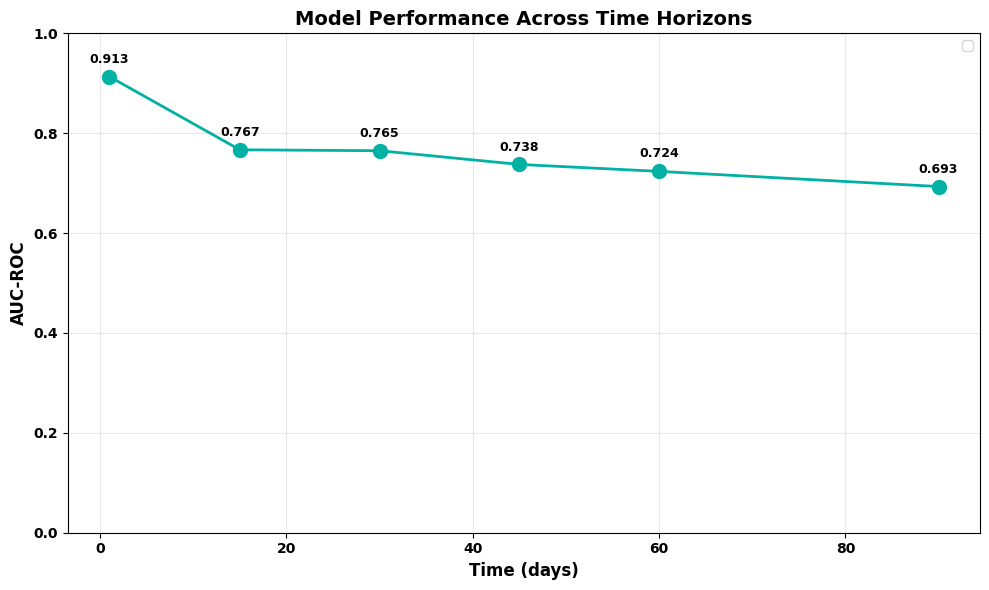


AUC Scores by Horizon:
  Day   1: 0.913
  Day  15: 0.767
  Day  30: 0.765
  Day  45: 0.738
  Day  60: 0.724
  Day  90: 0.693


In [ ]:
plot_auc_across_horizons(predictions, horizons)

In [ ]:
# ROC cruves
def plot_roc_curves(predictions, horizons):
    """Plot ROC curves for all time horizons"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        if not np.isnan(predictions[h]['auc']):
            y_true = predictions[h]['y_true']
            y_pred_proba = predictions[h]['y_pred_proba']

            fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
            auc = predictions[h]['auc']

            ax.plot(fpr, tpr, linewidth=2.5, label=f'AUC = {auc:.3f}', color='#00B1A4')
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.5)
            ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
            ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
            ax.set_title(f'ROC Curve - Day {h}', fontsize=12, fontweight='bold')
            ax.legend(loc='lower right', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.02, 1.02])
        else:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=12)
            ax.set_title(f'Day {h}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('single_model_roc_curves.png', dpi=500, bbox_inches='tight')
    plt.show()

In [ ]:
#plot_roc_curves(predictions, horizons)

In [ ]:
def plot_confusion_matrices(predictions, horizons, threshold=0.5):
    """Plot confusion matrices for all time horizons"""
    n_horizons = len(horizons)
    n_cols = 3
    n_rows = (n_horizons + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_horizons > 1 else [axes]

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        y_true = predictions[h]['y_true']
        y_pred_proba = predictions[h]['y_pred_proba']
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Plot
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   cbar=False, square=True,
                   xticklabels=['Survived', 'Died'],
                   yticklabels=['Survived', 'Died'])

        ax.set_title(f'Day {h} Confusion Matrix', fontsize=14, fontweight='bold')
        ax.set_ylabel('Actual', fontsize=12)
        ax.set_xlabel('Predicted', fontsize=12)

        # Calculate metrics
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        # Add metrics text
        metrics_text = f'Sensitivity: {sensitivity:.2%}\nSpecificity: {specificity:.2%}\nPPV: {ppv:.2%}\nNPV: {npv:.2%}'
        ax.text(1.05, 0.5, metrics_text,fontsize=10,va='center',
                transform=ax.transAxes,bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Remove extra subplots
    for idx in range(n_horizons, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig('confusion_matrices_all_horizons.png', dpi=500, bbox_inches='tight')
    plt.show()

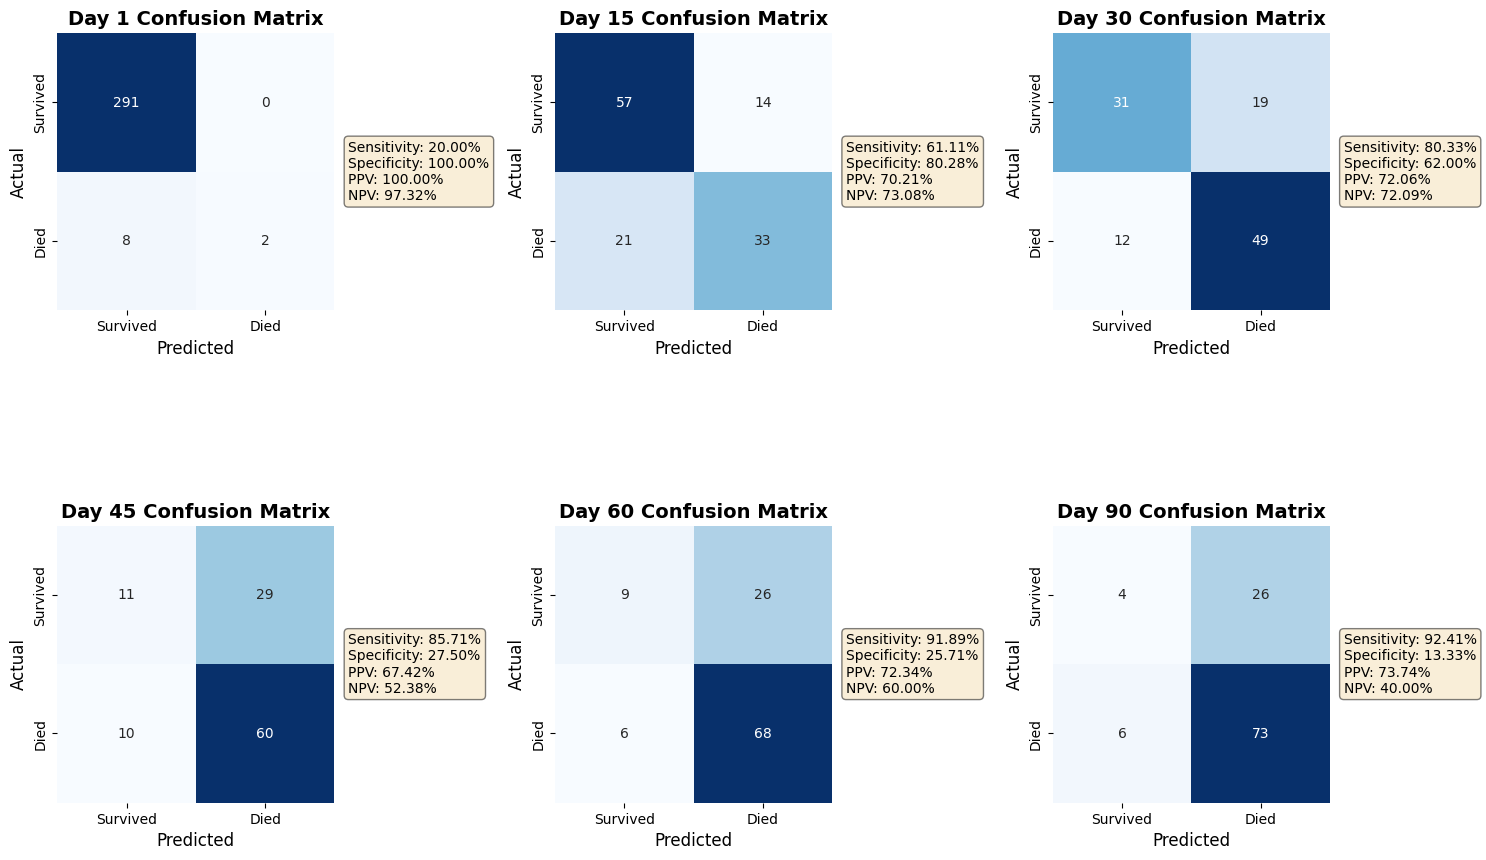

In [ ]:
plot_confusion_matrices(predictions, horizons, threshold=0.5)

In [ ]:
def plot_cm_plus_acc(predictions, horizons, threshold=0.5):
    """Plot confusion matrices for all time horizons with Accuracy"""
    n_horizons = len(horizons)
    n_cols = 3
    n_rows = (n_horizons + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_horizons > 1 else [axes]

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        y_true = predictions[h]['y_true']
        y_pred_proba = predictions[h]['y_pred_proba']
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Plot
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   cbar=False, square=True,
                   xticklabels=['Survived', 'Died'],
                   yticklabels=['Survived', 'Died'])

        ax.set_title(f'Day {h} Confusion Matrix', fontsize=14, fontweight='bold')
        ax.set_ylabel('Actual', fontsize=12)
        ax.set_xlabel('Predicted', fontsize=12)

        # Calculate metrics
        tn, fp, fn, tp = cm.ravel()
        total = tn + fp + fn + tp

        # New Metric: Accuracy
        accuracy = (tp + tn) / total if total > 0 else 0

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        # Updated metrics text to include Accuracy
        metrics_text = (f'Accuracy: {accuracy:.2%}\n'
                        f'Sensitivity: {sensitivity:.2%}\n'
                        f'Specificity: {specificity:.2%}\n'
                        f'PPV: {ppv:.2%}\n'
                        f'NPV: {npv:.2%}')

        ax.text(1.05, 0.5, metrics_text, fontsize=10, va='center',
                transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Remove extra subplots
    for idx in range(n_horizons, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig('confusion_matrices_all_horizons.png', dpi=500, bbox_inches='tight')
    plt.show()

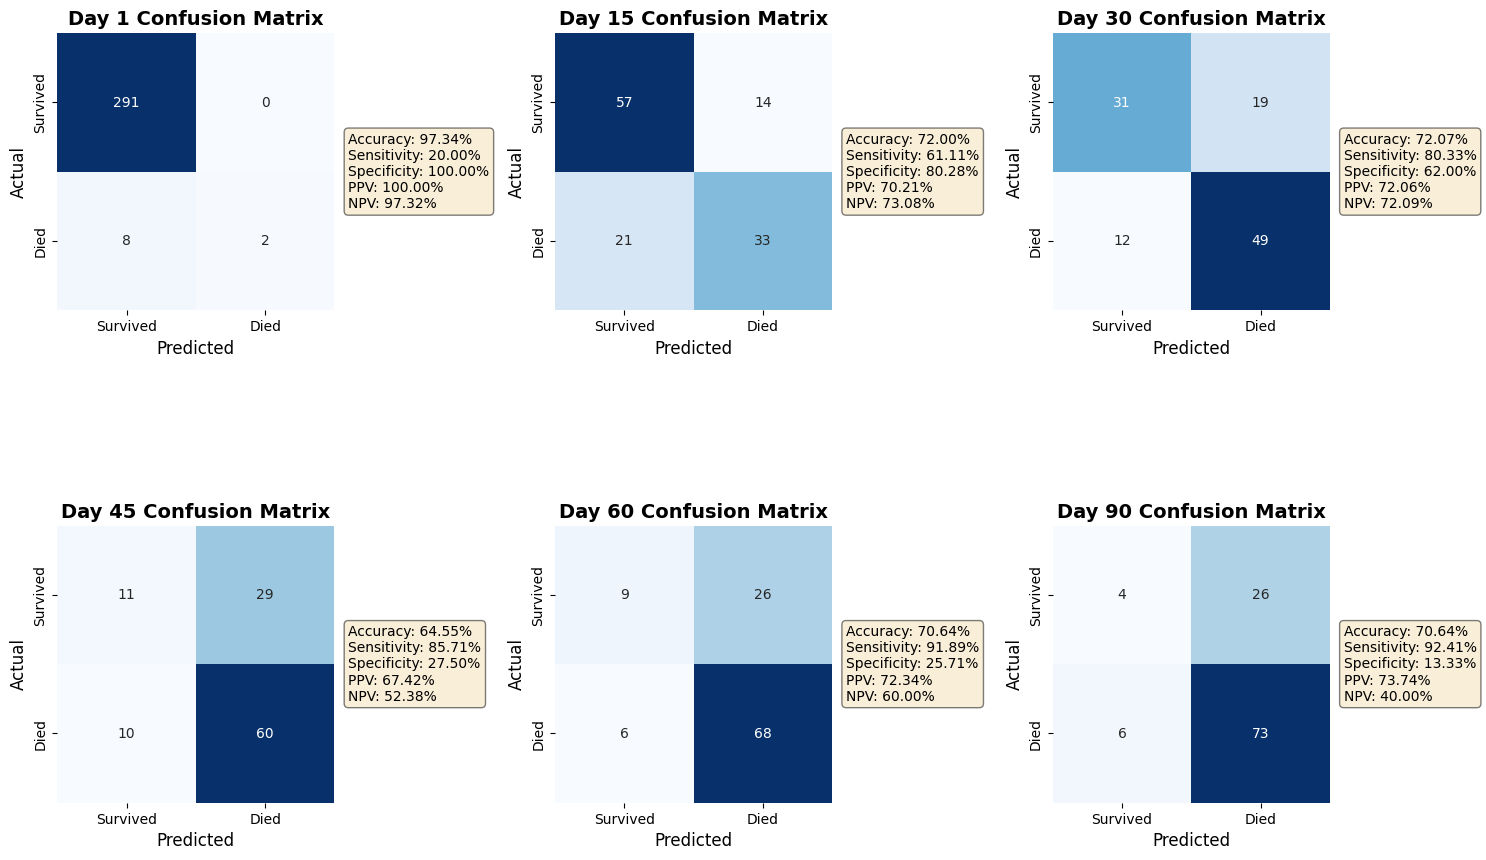

In [ ]:
plot_cm_plus_acc(predictions, horizons, threshold=0.5)

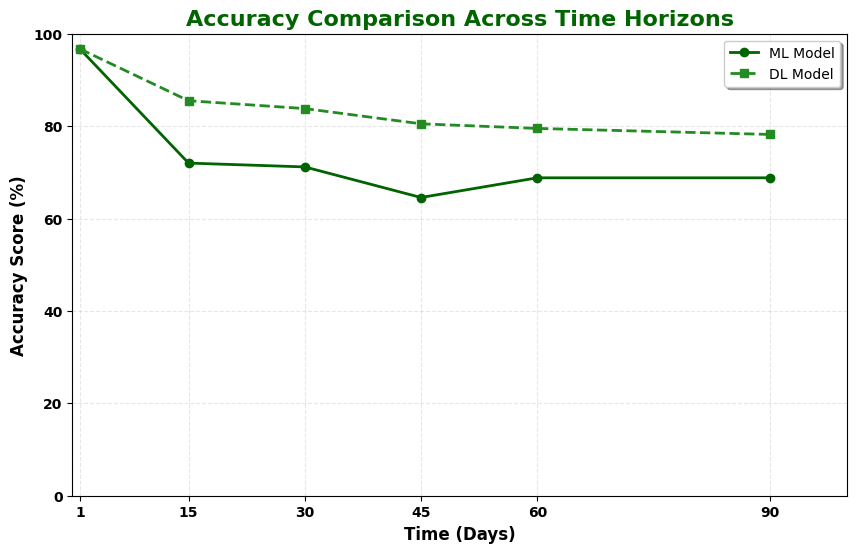

In [ ]:
horizons = [1, 15, 30, 45, 60, 90]
ml_model = [96.68, 72.00, 71.17, 64.55, 68.81, 68.81]
dl_model = [96.70, 85.50, 83.80, 80.50, 79.50, 78.20]

plt.figure(figsize=(10, 6))

plt.plot(horizons, ml_model, marker='o', linestyle='-',
         color='darkgreen', linewidth=2, label='ML Model')

plt.plot(horizons, dl_model, marker='s', linestyle='--',
         color='forestgreen', linewidth=2, label='DL Model')

plt.title('Accuracy Comparison Across Time Horizons', fontsize=16, fontweight='bold', color='darkgreen')
plt.xlabel('Time (Days)', fontsize=12, fontweight="bold")
plt.ylabel('Accuracy Score (%)', fontsize=12, fontweight="bold") # Clarify that this is %


plt.ylim(0, 100)
plt.xlim(0, 100)


plt.xticks(horizons, fontweight="bold")
plt.yticks(fontweight="bold")
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(frameon=True, shadow=True)


plt.savefig('accuracy_trend_green.png', dpi=500, bbox_inches='tight')
plt.show()

##### Explainability

In [ ]:
def plot_global_feature_importance(model, feature_names, top_n=25):
    """Plot feature importance from the single model (represents all horizons)"""
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 25 Most Important Features (Single Model - All Horizons):")
    print(feature_importance.head(25).to_string(index=False))

    plt.figure(figsize=(10, 12))
    top_features = feature_importance.head(top_n)

    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=10, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Most Important Features - Machine Learning Model',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('single_model_feature_importance_all.png', dpi=500, bbox_inches='tight')
    plt.show()

    return feature_importance

In [ ]:
#global_importance = plot_global_feature_importance(xgboost, X_train_expanded.columns, top_n=25)

In [ ]:
#global_importance = plot_global_feature_importance(xgboost, X_train_expanded.columns, top_n=5)

In [ ]:
# Top 25 important features
def plot_horizon_specific_importance(model, X_test_base, y_test_df, horizon, top_n=25):
    """
    Calculate feature importance for a specific horizon using permutation importance
    or by filtering predictions to that horizon
    """
    from sklearn.inspection import permutation_importance

    # Prepare test data for this specific horizon
    test_observable = y_test_df[f'observable_at_day_{horizon}']
    X_test_h = X_test_base[test_observable].copy()
    X_test_h['horizon'] = horizon
    y_test_h = y_test_df.loc[test_observable, f'died_by_day_{horizon}']

    print(f"\nCalculating permutation importance for {horizon}-day horizon...")
    print(f"Using {len(X_test_h)} test samples")

    # Calculate permutation importance
    perm_importance = permutation_importance(
        model, X_test_h, y_test_h,
        n_repeats=10,
        random_state=42,
        scoring='roc_auc'
    )

    feature_importance = pd.DataFrame({
        'Feature': X_test_h.columns,
        'Importance': perm_importance.importances_mean
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 25 Most Important Features ({horizon}-Day Horizon):")
    print(feature_importance.head(25).to_string(index=False))

    plt.figure(figsize=(10, 12))
    top_features = feature_importance.head(top_n)

    colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_features)))
    plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=10)
    plt.xlabel('Permutation Importance (AUC decrease)', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Most Important Features - {horizon}-Day Mortality',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'single_model_feature_importance_day_{horizon}.png', dpi=500, bbox_inches='tight')
    plt.show()

    return feature_importance


Calculating permutation importance for 1-day horizon...
Using 301 test samples

Top 25 Most Important Features (1-Day Horizon):
                               Feature  Importance
                                DOSAGE    0.137045
                              DURATION    0.014708
                  DETAILED_DESCRIPTION    0.012955
                      DISEASE_DISORDER    0.011512
                     care_level_medium    0.005739
                        blood_pressure    0.003849
                          readmissions    0.003711
                        race_NON-WHITE    0.003162
                                 Sex_F    0.003162
                 THERAPEUTIC_PROCEDURE    0.001993
                        CLINICAL_EVENT    0.001306
                     sc_History of TIA    0.000825
                          SIGN_SYMPTOM    0.000756
                               horizon    0.000000
                                 Sex_M    0.000000
sc_Hemorrhagic stroke + history of TIA    0.000000
    

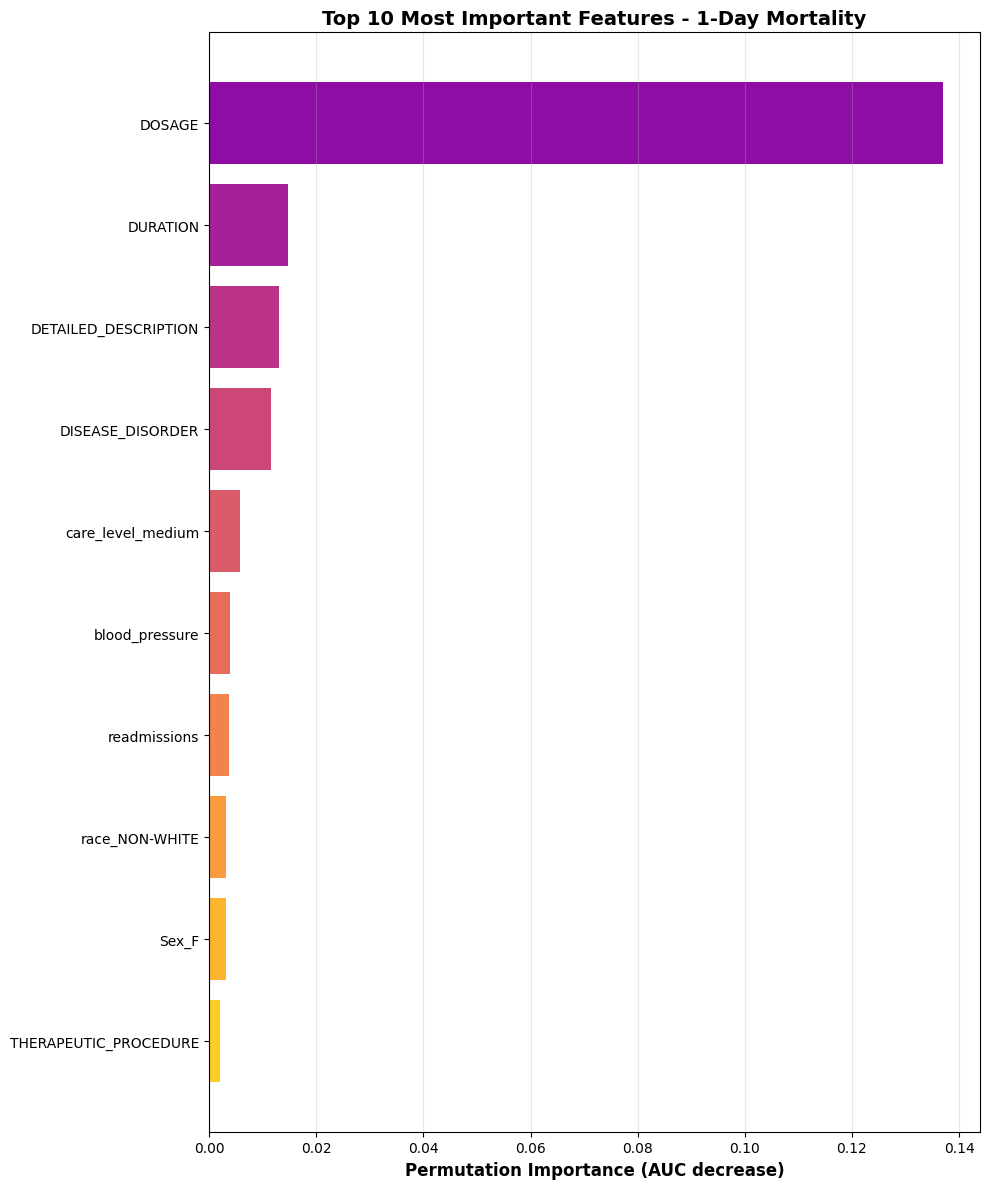

In [ ]:
day1_importance = plot_horizon_specific_importance(xgboost, X_test_base, y_test_df, horizon=1, top_n=10)

In [ ]:
# SHAP values - global
def plot_shap_global_importance_bar(model, X_test_base, y_test_df, horizon=1, sample_size=865, exclude_features=("horizon",)):
    """Calculate and plot SHAP values for a specific horizon,
       excluding specified features from explanation plots.
    """

    test_observable = y_test_df[f'observable_at_day_{horizon}']
    X_test_h = X_test_base[test_observable].copy()
    X_test_h['horizon'] = h

    sample_size = min(sample_size, len(X_test_h))
    X_test_sample = X_test_h.sample(n=sample_size, random_state=42)

    print(f"\nComputing SHAP values for {horizon}-day horizon...")
    print(f"Using {len(X_test_sample)} test samples")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_sample)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive class

    # Exclude features from plot
    keep_mask = ~X_test_sample.columns.isin(exclude_features)
    X_plot = X_test_sample.loc[:, keep_mask]
    shap_values_plot = shap_values[:, keep_mask]

    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values_plot, X_plot, plot_type="bar", max_display=20, show=False)
    plt.title(f"Global Feature Importance (SHAP) - {horizon}-Day Mortality", fontsize=14, fontweight='bold')
    plt.ylabel("Features", fontsize=14, fontweight="bold")
    plt.xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.yticks(fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.savefig(f'single_model_shap_global_day_1.png', dpi=500, bbox_inches='tight')
    plt.show()

    return explainer, shap_values, X_test_sample

In [ ]:
#explainer_1, shap_values_1, X_test_sample_1 = plot_shap_global_importance_bar(xgboost, X_test_base, y_test_df, horizon=1,sample_size=300)
#plt.show()

In [ ]:
# SHAP values - global
def plot_shap_global_importance_bee(model, X_test_base, y_test_df, horizon=1, sample_size=865, exclude_features=("horizon",)):
    """Calculate and plot SHAP values for a specific horizon,
       excluding specified features from explanation plots.
    """

    # Prepare test data for this horizon
    test_observable = y_test_df[f'observable_at_day_{horizon}']
    X_test_h = X_test_base[test_observable].copy()
    X_test_h['horizon'] = h

    # Sample for computational efficiency
    sample_size = min(sample_size, len(X_test_h))
    X_test_sample = X_test_h.sample(n=sample_size, random_state=42)

    print(f"\nComputing SHAP values for {horizon}-day horizon...")
    print(f"Using {len(X_test_sample)} test samples")

    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_sample)

    # For binary classification, shap_values might be a list
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive class

    # Exclude features from plots
    keep_mask = ~X_test_sample.columns.isin(exclude_features)

    X_plot = X_test_sample.loc[:, keep_mask]
    shap_values_plot = shap_values[:, keep_mask]

    # Detailed SHAP summary plot (beeswarm)
    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values_plot, X_plot, max_display=25, show=False)
    plt.title(f"Feature Effects on {horizon}-Day Mortality Risk", fontsize=14, fontweight='bold')
    plt.xlabel('SHAP Value', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.yticks(fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.savefig(f'bee_single_model_shap_global_day_1.png', dpi=500, bbox_inches='tight')
    plt.show()

    return explainer, shap_values, X_test_sample


Computing SHAP values for 1-day horizon...
Using 301 test samples


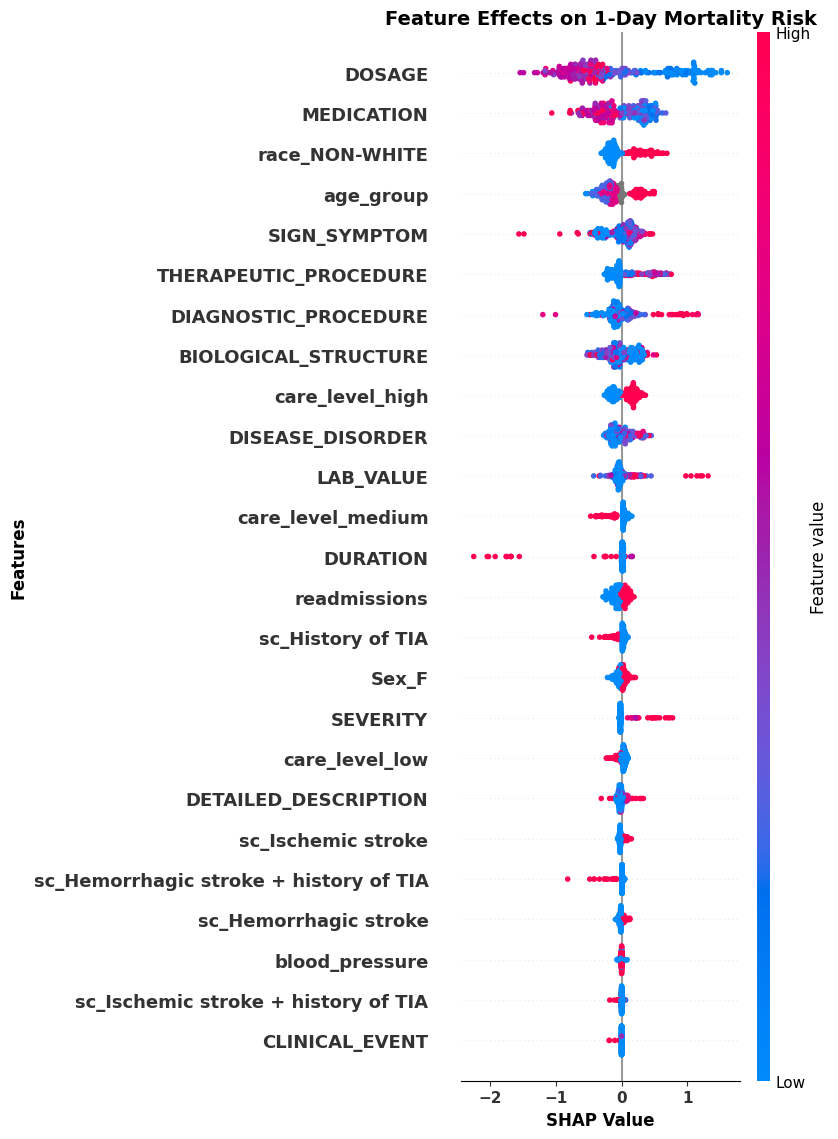

In [ ]:
explainer_1, shap_values_1, X_test_sample_1 = plot_shap_global_importance_bee(xgboost, X_test_base, y_test_df, horizon=1,sample_size=865)

In [ ]:
# SHAP for single patient
def plot_patient_waterfall(explainer, shap_values_full, X_test_sample_full, patient_idx=0, exclude_features=("horizon",)):
    """Create SHAP waterfall plot for a specific patient"""

    if patient_idx >= len(X_test_sample_full):
        patient_idx = 0
        print(f"Patient index out of range, using first patient (index 0)")

    # Get patient's full data and SHAP values
    patient_full_data = X_test_sample_full.iloc[patient_idx:patient_idx+1].copy()
    patient_shap_full = shap_values_full[patient_idx]

    # Filter features for plotting
    keep_mask = ~patient_full_data.columns.isin(exclude_features)
    X_plot_patient = patient_full_data.loc[:, keep_mask]
    # Filter SHAP values based on the same mask
    original_columns = patient_full_data.columns.tolist()
    kept_feature_indices = [original_columns.index(col) for col in X_plot_patient.columns]
    patient_shap_plot = patient_shap_full[kept_feature_indices]


    print(f"\nPatient 1-Day Mortality Risk – Feature Contributions")
    print(f"{'='*60}")

    # Top contributing features for display (using filtered data for plot display)
    feature_contributions = pd.DataFrame({
        'Feature': X_plot_patient.columns,
        'Value': X_plot_patient.iloc[0].values,
        'SHAP Impact': patient_shap_plot
    }).sort_values('SHAP Impact', key=abs, ascending=False)

    print("\nTop 10 Contributing Features:")
    print(feature_contributions.head(10).to_string(index=False))

    # Calculate predicted probability
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

    # SHAP waterfall plot
    plt.figure(figsize=(8, 8))
    shap.waterfall_plot(
        shap.Explanation(
            values=patient_shap_plot,
            base_values=base_value,
            data=X_plot_patient.iloc[0].values,
            feature_names=X_plot_patient.columns.tolist()
        ),
        max_display=10,
        show=False
    )

    plt.title('Patient 1-Day Mortality Risk',
              fontsize=14, fontweight='bold', pad=20)
    plt.yticks(fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.tight_layout()
    plt.savefig('single_model_patient_waterfall_pos.png', dpi=500)
    plt.show()

    # Predicted probability for context (using full patient data for prediction)
    patient_full_data_aligned = patient_full_data[X_train_expanded.columns] # Reindex to match training columns
    pred_proba = xgboost.predict_proba(patient_full_data_aligned)[0, 1]
    print(f"\nPredicted 1-day mortality risk: {pred_proba:.1%}")

    return feature_contributions.head(9)


Patient 1-Day Mortality Risk – Feature Contributions

Top 10 Contributing Features:
              Feature    Value  SHAP Impact
               DOSAGE 0.000000     1.129013
 DIAGNOSTIC_PROCEDURE 0.214286     0.888644
           MEDICATION 0.071429     0.444882
            age_group 2.000000    -0.287771
    care_level_medium 1.000000    -0.248980
         SIGN_SYMPTOM 0.428571     0.176762
       race_NON-WHITE 1.000000     0.158333
      care_level_high 0.000000    -0.130238
            LAB_VALUE 0.071429    -0.123965
THERAPEUTIC_PROCEDURE 0.000000    -0.081539


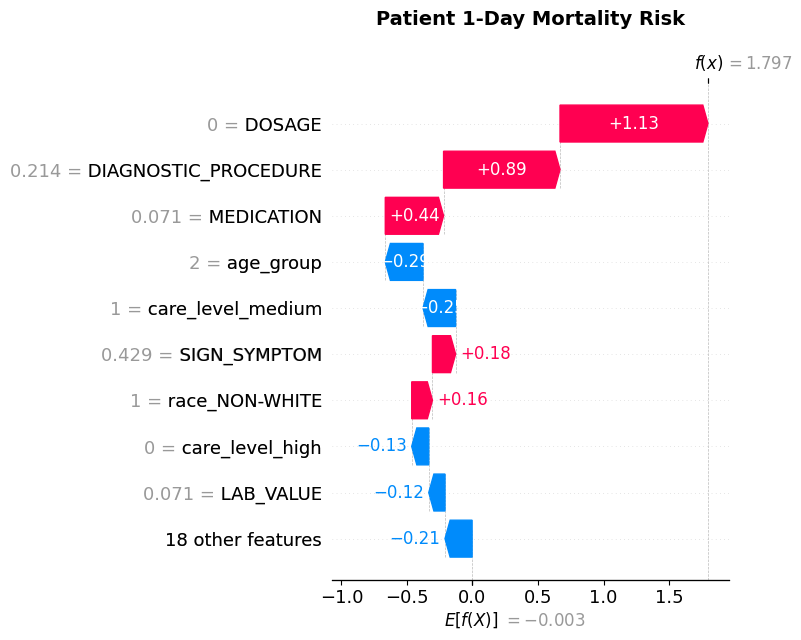


Predicted 1-day mortality risk: 97.8%


In [ ]:
# Plot SHAP for first patient
patient_contributions = plot_patient_waterfall(explainer_1, shap_values_1, X_test_sample_1, patient_idx=2)
plt.show()

In [ ]:
X_test_sample_1.head()

,age_group,blood_pressure,Sex_F,Sex_M,race_NON-WHITE,race_WHITE,sc_Hemorrhagic stroke,sc_Hemorrhagic stroke + history of TIA,sc_History of TIA,sc_Ischemic stroke,...,DISEASE_DISORDER,BIOLOGICAL_STRUCTURE,LAB_VALUE,DIAGNOSTIC_PROCEDURE,SEVERITY,THERAPEUTIC_PROCEDURE,CLINICAL_EVENT,DETAILED_DESCRIPTION,DURATION,horizon
177,5.0,0,0,1,0,1,1,0,0,0,...,0.032258,0.064516,0.000000,0.000000,0.0,0.032258,0.0,0.000000,0.0,90
291,5.0,0,0,1,0,1,0,0,1,0,...,0.000000,0.011494,0.114943,0.183908,0.0,0.000000,0.0,0.000000,0.0,90
229,2.0,1,0,1,1,0,0,0,0,1,...,0.071429,0.142857,0.071429,0.214286,0.0,0.000000,0.0,0.000000,0.0,90
199,2.0,1,1,0,1,0,0,0,0,1,...,0.217391,0.000000,0.043478,0.260870,0.0,0.000000,0.0,0.000000,0.0,90
60,NaN,1,1,0,0,1,1,0,0,0,...,0.035714,0.142857,0.000000,0.000000,0.0,0.000000,0.0,0.071429,0.0,90


### Explainability with LIME

In [ ]:
def xgboost_predict_proba(X):
    return xgboost.predict_proba(X)

In [ ]:
# Use a representative subset of training data
lime_background = X_train_expanded.sample(n=min(1000, len(X_train_expanded)),random_state=42)

lime_explainer = LimeTabularExplainer(training_data=lime_background.values,feature_names=lime_background.columns.tolist(),
                                      class_names=["Survived", "Died"],mode="regression",discretize_continuous=True,verbose=False)

In [ ]:
patient_idx = 0
# Select patient from test set
patient = X_test_base.iloc[patient_idx:patient_idx+1].copy()
patient["horizon"] = 1
# Ensure column order matches training
patient = patient[X_train_expanded.columns]

In [ ]:
# Find zero or near-zero variance features
variances = X_train_expanded.var()

bad_cols = variances[variances <= 1e-8]
print("Problematic columns (zero / near-zero variance):")
print(bad_cols)

Problematic columns (zero / near-zero variance):
Series([], dtype: float64)


In [ ]:
# Drop zero-variance columns for LIME background
lime_safe_cols = variances[variances > 1e-8].index.tolist()
X_train_lime = X_train_expanded[lime_safe_cols]

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
lime_background = X_train_lime.sample(
    n=min(1000, len(X_train_lime)),
    random_state=42)
lime_explainer = LimeTabularExplainer(
    training_data=lime_background.values,
    feature_names=lime_background.columns.tolist(),
    class_names=["Survived", "Died"],
    mode="classification",
    discretize_continuous=True)

In [ ]:
X_train_lime_processed = X_train_expanded.copy()
X_test_sample_1_processed = X_test_sample_1.copy()

mean_age_group = X_train_lime_processed['age_group'].mean()
X_train_lime_processed['age_group'] = X_train_lime_processed['age_group'].fillna(mean_age_group)
X_test_sample_1_processed['age_group'] = X_test_sample_1_processed['age_group'].fillna(mean_age_group)

variances_processed = X_train_lime_processed.var()
zero_variance_cols = variances_processed[variances_processed <= 1e-8].index.tolist()

X_train_lime_filtered = X_train_lime_processed.drop(columns=zero_variance_cols, errors='ignore')

lime_background = X_train_lime_filtered.sample(
    n=min(1000, len(X_train_lime_filtered)),
    random_state=42)
lime_explainer_filtered = LimeTabularExplainer(
    training_data=lime_background.values,
    feature_names=lime_background.columns.tolist(),
    class_names=["Survived", "Died"],
    mode="classification",
    discretize_continuous=False)

patient_idx = 2
patient_full = X_test_sample_1_processed.iloc[patient_idx:patient_idx+1].copy()
patient_full["horizon"] = 1

patient_lime = patient_full[X_train_lime_filtered.columns]

lime_exp = lime_explainer_filtered.explain_instance(
    data_row=patient_lime.values[0],
    predict_fn=xgboost_predict_proba,
    num_features=10
)

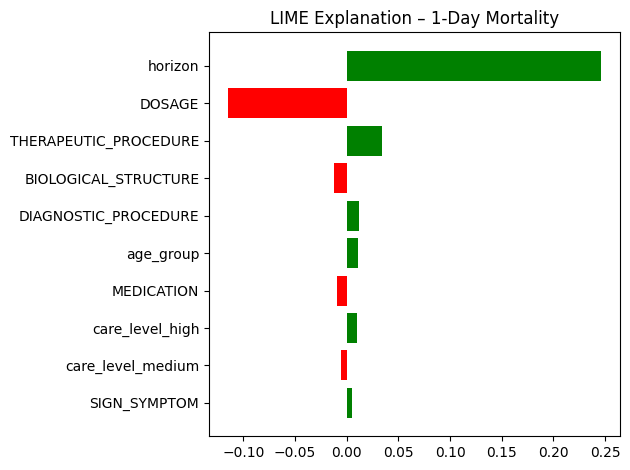

In [ ]:
fig = lime_exp.as_pyplot_figure()
plt.title("LIME Explanation – 1-Day Mortality")
plt.savefig('lime_explanation_ml_neg_reg.png', dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
lime_exp.show_in_notebook()

In [ ]:
! pip install imgkit

In [ ]:
import imgkit

lime_exp.save_to_file('temp_2.html')
options = {
    'format': 'png',
    'enable-local-file-access': None,
    'quality': 500
}